# Свечи по лучшим trial (несколько методов / пациентов)

Запуск по порядку: **настройка PYTHONPATH** → **загрузка `.db` и `best_df`** → **график (Optuna)** → опционально **график + Transformer (fixed)** из JSON-отчёта.

Правило имён: `tfr_<patient>_<method>.db` (суффикс метода может содержать `_`, напр. `tfr_svm`).

Детальный разбор одного study см. `open_study_and_visualise.ipynb`.


In [1]:
import sys
from pathlib import Path

_cwd = Path.cwd().resolve()
_cands = [_cwd, _cwd.parent, *_cwd.parents[:3]]
project_root = next((p for p in _cands if (p / "lib" / "optuna").is_dir()), None)
if project_root is None:
    raise FileNotFoundError(
        "NeuronDeCo root not found (expected directory with lib/optuna). "
        f"cwd={_cwd}"
    )
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from IPython.display import display
from optuna.trial import TrialState

from lib.optuna import load_study_sqlite

print("project_root:", project_root)

project_root: /beegfs/home/t.samsonov/notebooks/Pirogov/NeuronDeCo


In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
from optuna.trial import TrialState

from lib.optuna import load_study_sqlite


def select_best_trial_top5_f1_then_min_loss(study):
    """Top-5 by F1, then choose one with minimum loss."""
    complete_trials = [
        t
        for t in study.get_trials(deepcopy=False)
        if t.state == TrialState.COMPLETE and t.values is not None and len(t.values) >= 2
    ]
    if not complete_trials:
        return None

    ranked_by_f1 = sorted(complete_trials, key=lambda t: float(t.values[0]), reverse=True)
    top5 = ranked_by_f1[:5]
    best = min(top5, key=lambda t: float(t.values[1]))
    return best


# Несколько каталогов: один .stem — последний перечисленный каталог побеждает.
# method = суффикс после tfr_<patient>_ (transformer, alexnet, tfr_svm, …).
RUN_DIRS = (
    Path("../../PreprocessedData/2026-04-01"),
    Path("../../PreprocessedData/2026-05-10"),
)

by_stem: dict[str, Path] = {}
for d in RUN_DIRS:
    d = Path(d).expanduser().resolve()
    if not d.is_dir():
        continue
    for p in sorted(d.glob("tfr_*_*.db")):
        by_stem[p.stem] = p.resolve()

db_paths = sorted(by_stem.values(), key=lambda p: p.stem)
if not db_paths:
    raise FileNotFoundError(f"No studies found under RUN_DIRS={RUN_DIRS!r}")

study_rows = []
best_rows = []

for db_path in db_paths:
    stem = db_path.stem
    parts = stem.split("_")
    if len(parts) < 3:
        continue
    patient_id = parts[1]
    method = "_".join(parts[2:])

    study = load_study_sqlite(db_path=db_path, study_name=stem)

    complete_trials = [
        t
        for t in study.get_trials(deepcopy=False)
        if t.state == TrialState.COMPLETE and t.values is not None and len(t.values) >= 2
    ]
    for t in complete_trials:
        study_rows.append(
            {
                "patient": patient_id,
                "method": method,
                "trial_number": int(t.number),
                "f1": float(t.values[0]),
                "loss": float(t.values[1]),
            }
        )

    best_trial = select_best_trial_top5_f1_then_min_loss(study)
    if best_trial is not None:
        best_rows.append(
            {
                "patient": patient_id,
                "method": method,
                "trial_number": int(best_trial.number),
                "f1": float(best_trial.values[0]),
                "loss": float(best_trial.values[1]),
                "params": best_trial.params,
                "db_path": str(db_path),
            }
        )

trials_df = pd.DataFrame(study_rows)
best_df = pd.DataFrame(best_rows).sort_values(["patient", "method"]).reset_index(drop=True)

print(f"Loaded studies: {len(db_paths)}")
print(f"Complete trial rows: {len(trials_df)}")
print("\nBest trial per patient/method (top5 F1 -> min loss):")
display(best_df[["patient", "method", "trial_number", "f1", "loss", "params"]])

Loaded studies: 36
Complete trial rows: 2520

Best trial per patient/method (top5 F1 -> min loss):


,patient,method,trial_number,f1,loss,params
0,s02,alexnet,8,0.784799,0.748842,"{'batch_size': 64, 'dropout': 0.59774686436186..."
1,s02,tfr_svm,43,0.721386,0.571214,"{'preprocess': 'pixel_weight', 'batch_size': 6..."
2,s02,transformer,41,0.810443,0.698228,"{'embed_dim': 256, 'preprocess': 'pixel_weight..."
3,s03,alexnet,7,0.892841,0.375702,"{'batch_size': 32, 'dropout': 0.46285456092819..."
4,s03,tfr_svm,76,0.874783,0.336524,"{'preprocess': 'pixel_weight', 'batch_size': 6..."
5,s03,transformer,98,0.875000,0.837953,"{'embed_dim': 32, 'preprocess': 'channel_conv'..."
6,s04,alexnet,8,0.862534,0.604550,"{'batch_size': 32, 'dropout': 0.38138515196064..."
7,s04,tfr_svm,61,0.743520,0.539220,"{'preprocess': 'ft_plane_conv', 'batch_size': ..."
8,s04,transformer,82,0.881944,0.460328,"{'embed_dim': 128, 'preprocess': 'flatten', 'b..."
9,s05,alexnet,1,0.683333,1.099249,"{'batch_size': 32, 'dropout': 0.49565080445723..."


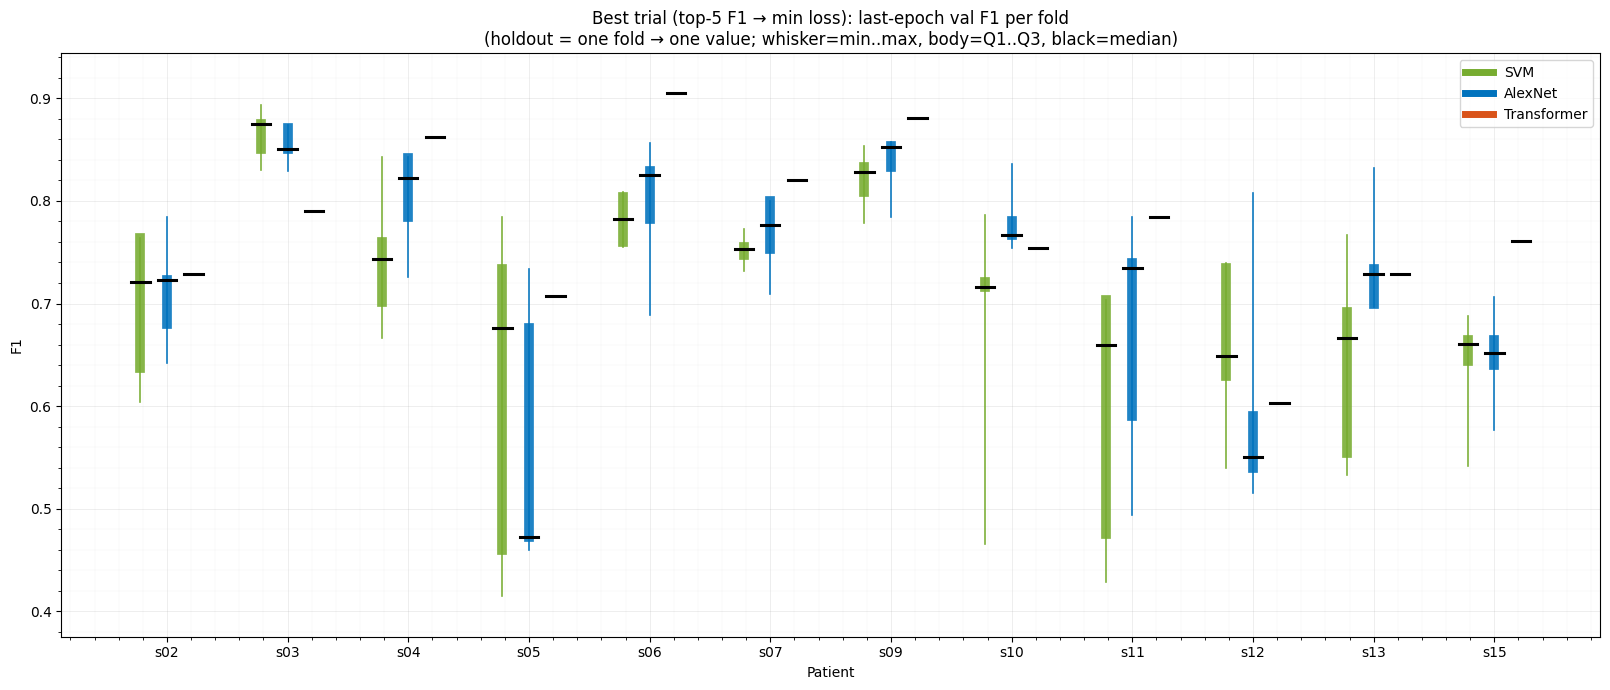

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib import cm as mpl_cm
from matplotlib.lines import Line2D
from pathlib import Path

from lib.optuna import load_study_sqlite


if best_df.empty:
    raise RuntimeError("No best trials. Run previous cell first.")

# Столбцы на графике (порядок). None → все методы из best_df + хвост «не упомянутые».
METHODS_ORDER: list[str] | None = ["tfr_svm", "alexnet", "transformer"]


def _last_epoch_f1_per_fold(row) -> np.ndarray:
    """
    F1 на последней эпохе каждого фолда (одно число на фолд).
    Holdout → одна точка на свечу; CV → несколько.
    """
    db_path = Path(row["db_path"])
    study = load_study_sqlite(db_path=db_path, study_name=db_path.stem)
    trial_num = int(row["trial_number"])
    tr = next(t for t in study.get_trials(deepcopy=False) if int(t.number) == trial_num)
    fold_curves = tr.user_attrs.get("fold_curves", None) or []
    vals: list[float] = []
    for fc in fold_curves:
        f1s = fc.get("val_f1s", []) or []
        if f1s:
            vals.append(float(f1s[-1]))
    if vals:
        return np.asarray(vals, dtype=np.float64)
    flat = tr.user_attrs.get("val_f1s", []) or []
    if flat:
        return np.asarray([float(flat[-1])], dtype=np.float64)
    return np.asarray([], dtype=np.float64)


_default_method_labels = {
    "tfr_svm": "SVM",
    "alexnet": "AlexNet",
    "transformer": "Transformer",

}
_default_method_colors = {
    "tfr_svm": (0.466, 0.674, 0.188),
    "alexnet": (0.0, 0.447, 0.741),
    "transformer": (0.85, 0.325, 0.098),
}


def _label_for_method(m: str) -> str:
    if m in _default_method_labels:
        return _default_method_labels[m]
    return " ".join(p.capitalize() for p in m.replace("_", " ").split())


def _color_for_method(m: str) -> tuple[float, float, float]:
    if m in _default_method_colors:
        return _default_method_colors[m]
    tab = mpl_cm.get_cmap("tab10")
    hue = abs(hash(m)) % 5237 / 5237.0
    return tuple(float(x) for x in tab(hue)[:3])

lookup = best_df.set_index(["patient", "method"])
patient_order = sorted(best_df["patient"].unique())
uniq_methods = sorted(best_df["method"].unique())
if METHODS_ORDER is None:
    methods_order = uniq_methods
else:
    head = [m for m in METHODS_ORDER if m in set(uniq_methods)]
    tail = [m for m in uniq_methods if m not in head]
    methods_order = head + tail

if not methods_order:
    raise RuntimeError("methods_order empty; check METHODS_ORDER and best_df")

n_m = len(methods_order)
fig_w_scale = max(1.0, 0.45 * (n_m - 1))
fig, ax = plt.subplots(figsize=(max(12.0, len(patient_order) * 1.35 * fig_w_scale), 7.0))

ax.set_axisbelow(True)
ax.grid(which="major", axis="both", linestyle="-", linewidth=0.6, alpha=0.25)
ax.grid(which="minor", axis="both", linestyle="-", linewidth=0.35, alpha=0.12)
ax.minorticks_on()

base_x = np.arange(len(patient_order), dtype=float)
if n_m <= 1:
    shifts = np.array([0.0])
else:
    step = float(min(0.22, 0.82 / max(n_m - 1, 1)))
    shifts = (np.arange(n_m, dtype=float) - (n_m - 1) / 2.0) * step
box_width = float(min(0.22, 0.06 + 0.16 / np.sqrt(max(n_m, 2))))

all_y = []

for m_idx, method in enumerate(methods_order):
    color = _color_for_method(method)
    shift = float(shifts[m_idx])

    for p_idx, patient in enumerate(patient_order):
        key = (patient, method)
        if key not in lookup.index:
            continue
        row = lookup.loc[key]
        if isinstance(row, pd.DataFrame):
            row = row.iloc[0]

        f1_vals = _last_epoch_f1_per_fold(row)
        if f1_vals.size == 0:
            continue

        x = base_x[p_idx] + shift
        vmin = float(np.min(f1_vals))
        vmax = float(np.max(f1_vals))
        q1 = float(np.quantile(f1_vals, 0.25))
        q3 = float(np.quantile(f1_vals, 0.75))
        med = float(np.median(f1_vals))
        all_y.extend([vmin, vmax])

        ax.plot([x, x], [vmin, vmax], color=color, linewidth=1.2, alpha=0.95, zorder=2)
        ax.plot([x, x], [q1, q3], color=color, linewidth=7.0, alpha=0.88, zorder=4)
        ax.plot([x - box_width / 2, x + box_width / 2], [med, med], color="black", linewidth=2.2, zorder=5)

ax.set_xticks(base_x)
ax.set_xticklabels(patient_order)
ax.set_xlabel("Patient")
ax.set_ylabel("F1")
ax.set_title(
    "Best trial (top-5 F1 → min loss): last-epoch val F1 per fold\n"
    "(holdout = one fold → one value; whisker=min..max, body=Q1..Q3, black=median)"
)

if all_y:
    ymin, ymax = min(all_y), max(all_y)
    pad = max(0.02, 0.08 * (ymax - ymin if ymax > ymin else 1.0))
    ax.set_ylim(ymin - pad, ymax + pad)

legend_handles = [
    Line2D([0], [0], color=_color_for_method(m), lw=5, label=_label_for_method(m))
    for m in methods_order
    if not best_df[(best_df["method"] == m)].empty
]
ax.legend(handles=legend_handles, loc="best", frameon=True)

plt.tight_layout()
plt.show()

### Transformer с фиксированными параметрами (JSON-отчёт)

После ячейки со **`best_df`**. Можно **вместо** предыдущей графика: те же свечи по Optuna (alexnet / transformer / svm из `best_df`) плюс серия **`transformer_fixed`** из файла **`_TRANSFORMER_FIXED_PARAMS_REPORT.json`** (`run_transformer_fixed_params_all_patients.py`). F1 по фолдам — последний элемент `val_f1s` в каждом фолде; если кривых нет — одна точка `f1_aggregate`.

Loaded fixed report: /beegfs/home/t.samsonov/notebooks/Pirogov/PreprocessedData/2026-05-11/_TRANSFORMER_FIXED_PARAMS_REPORT.json


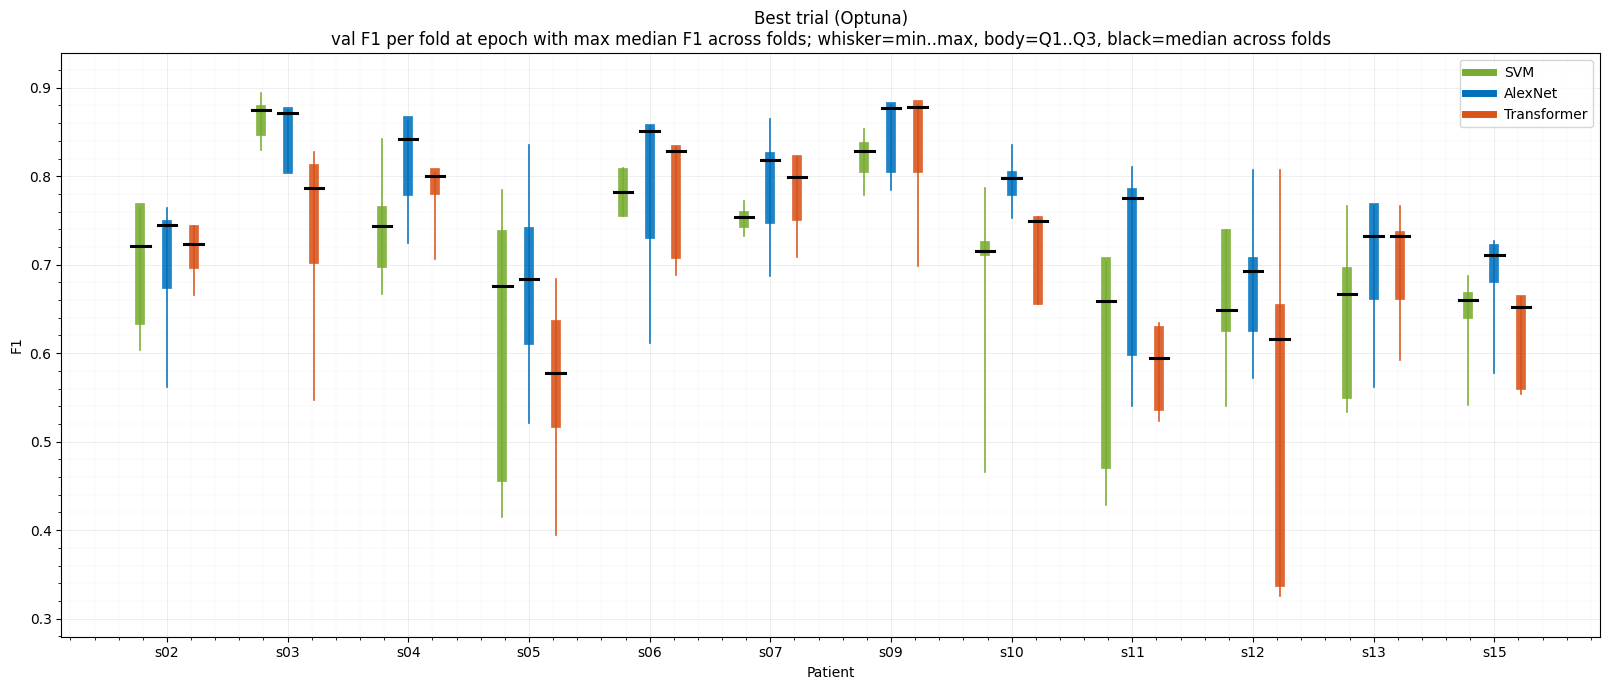

In [8]:
# Запуск после ячейки с best_df. Опционально заменяет предыдущий график: Optuna-свечи + transformer_fixed из JSON-отчёта.

import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib import cm as mpl_cm
from matplotlib.lines import Line2D

from lib.optuna import load_study_sqlite

if best_df.empty:
    raise RuntimeError("Сначала выполните ячейку со сбором best_df.")

# Путь к отчёту run_transformer_fixed_params_all_patients.py (или None — только Optuna-методы)
FIXED_REPORT_JSON = Path(
    "../../PreprocessedData/2026-05-11/_TRANSFORMER_FIXED_PARAMS_REPORT.json"
)
# FIXED_REPORT_JSON = None

METHODS_ORDER_BASE: list[str] | None = ["tfr_svm", "alexnet"]
# Методы из best_df, не попавшие в BASE, добавляются в хвост, кроме исключений (например старый Optuna-transformer).
OPTUNA_METHODS_EXCLUDE: frozenset[str] = frozenset({"transformer"})


def _f1_per_fold_at_best_median_epoch(series_list: list[np.ndarray]) -> np.ndarray:
    """По одному F1 на фолд: значение в эпохе t*, где t* максимизирует медиану F1 по фолдам (длина — min по фолдам)."""
    arrs = [np.asarray(s, dtype=np.float64).ravel() for s in series_list if np.size(s)]
    if not arrs:
        return np.asarray([], dtype=np.float64)
    t_max = min(int(a.shape[0]) for a in arrs)
    if t_max <= 0:
        return np.asarray([], dtype=np.float64)
    stack = np.stack([a[:t_max] for a in arrs], axis=0)
    med = np.median(stack, axis=0)
    t_star = int(np.argmax(med))
    return stack[:, t_star].astype(np.float64)


def _best_median_epoch_f1_per_fold(row) -> np.ndarray:
    db_path = Path(row["db_path"])
    study = load_study_sqlite(db_path=db_path, study_name=db_path.stem)
    trial_num = int(row["trial_number"])
    tr = next(t for t in study.get_trials(deepcopy=False) if int(t.number) == trial_num)
    fold_curves = tr.user_attrs.get("fold_curves", None) or []
    series: list[np.ndarray] = []
    for fc in fold_curves:
        f1s = fc.get("val_f1s", []) or []
        if f1s:
            series.append(np.asarray(f1s, dtype=np.float64))
    if series:
        return _f1_per_fold_at_best_median_epoch(series)
    flat = np.asarray(tr.user_attrs.get("val_f1s", []) or [], dtype=np.float64).ravel()
    if flat.size:
        t_star = int(np.argmax(flat))
        return np.asarray([float(flat[t_star])], dtype=np.float64)
    return np.asarray([], dtype=np.float64)


def _f1_vals_fixed(patient: str, rep: dict) -> np.ndarray:
    ps = rep.get("per_subject", {}).get(patient)
    if ps is None:
        return np.asarray([], dtype=np.float64)
    series: list[np.ndarray] = []
    for fc in ps.get("folds", []) or []:
        cur = (fc.get("curves") or {}).get("val_f1s") or []
        if cur:
            series.append(np.asarray(cur, dtype=np.float64))
    if series:
        return _f1_per_fold_at_best_median_epoch(series)
    if "f1_aggregate" in ps:
        return np.asarray([float(ps["f1_aggregate"])], dtype=np.float64)
    return np.asarray([], dtype=np.float64)


_default_method_labels = {
    "tfr_svm": "SVM",
    "alexnet": "AlexNet",
    "transformer": "Transformer",
    "transformer_fixed": "Transformer",
}
_default_method_colors = {
    "tfr_svm": (0.466, 0.674, 0.188),
    "alexnet": (0.0, 0.447, 0.741),
    "transformer": (0.85, 0.325, 0.098),
    "transformer_fixed": (0.85, 0.325, 0.098),
}


def _label_for_method(m: str) -> str:
    if m in _default_method_labels:
        return _default_method_labels[m]
    return " ".join(p.capitalize() for p in m.replace("_", " ").split())


def _color_for_method(m: str) -> tuple[float, float, float]:
    if m in _default_method_colors:
        return _default_method_colors[m]
    tab = mpl_cm.get_cmap("tab10")
    hue = abs(hash(m)) % 5237 / 5237.0
    return tuple(float(x) for x in tab(hue)[:3])


fixed_rep: dict | None = None
if FIXED_REPORT_JSON is not None:
    fp = Path(FIXED_REPORT_JSON).expanduser().resolve()
    if fp.is_file():
        with open(fp, encoding="utf-8") as fh:
            fixed_rep = json.load(fh)
        print("Loaded fixed report:", fp)
    else:
        print("Fixed report not found (skip series):", fp)

lookup = best_df.set_index(["patient", "method"])
patient_order = sorted(best_df["patient"].unique())
uniq_methods = sorted(best_df["method"].unique())
if METHODS_ORDER_BASE is None:
    methods_order = [m for m in uniq_methods if m not in OPTUNA_METHODS_EXCLUDE]
else:
    head = [m for m in METHODS_ORDER_BASE if m in set(uniq_methods)]
    tail = [m for m in uniq_methods if m not in head and m not in OPTUNA_METHODS_EXCLUDE]
    methods_order = head + tail

if fixed_rep is not None and "transformer_fixed" not in methods_order:
    methods_order = list(methods_order) + ["transformer_fixed"]

if not methods_order:
    raise RuntimeError("methods_order empty")

n_m = len(methods_order)
fig_w_scale = max(1.0, 0.45 * (n_m - 1))
fig, ax = plt.subplots(figsize=(max(12.0, len(patient_order) * 1.35 * fig_w_scale), 7.0))

ax.set_axisbelow(True)
ax.grid(which="major", axis="both", linestyle="-", linewidth=0.6, alpha=0.25)
ax.grid(which="minor", axis="both", linestyle="-", linewidth=0.35, alpha=0.12)
ax.minorticks_on()

base_x = np.arange(len(patient_order), dtype=float)
if n_m <= 1:
    shifts = np.array([0.0])
else:
    step = float(min(0.22, 0.82 / max(n_m - 1, 1)))
    shifts = (np.arange(n_m, dtype=float) - (n_m - 1) / 2.0) * step
box_width = float(min(0.22, 0.06 + 0.16 / np.sqrt(max(n_m, 2))))

all_y: list[float] = []

for m_idx, method in enumerate(methods_order):
    color = _color_for_method(method)
    shift = float(shifts[m_idx])

    for p_idx, patient in enumerate(patient_order):
        if method == "transformer_fixed":
            if fixed_rep is None:
                continue
            f1_vals = _f1_vals_fixed(patient, fixed_rep)
        else:
            key = (patient, method)
            if key not in lookup.index:
                continue
            row = lookup.loc[key]
            if isinstance(row, pd.DataFrame):
                row = row.iloc[0]
            f1_vals = _best_median_epoch_f1_per_fold(row)

        if f1_vals.size == 0:
            continue

        x = base_x[p_idx] + shift
        vmin = float(np.min(f1_vals))
        vmax = float(np.max(f1_vals))
        q1 = float(np.quantile(f1_vals, 0.25))
        q3 = float(np.quantile(f1_vals, 0.75))
        med = float(np.median(f1_vals))
        all_y.extend([vmin, vmax])

        ax.plot([x, x], [vmin, vmax], color=color, linewidth=1.2, alpha=0.95, zorder=2)
        ax.plot([x, x], [q1, q3], color=color, linewidth=7.0, alpha=0.88, zorder=4)
        ax.plot([x - box_width / 2, x + box_width / 2], [med, med], color="black", linewidth=2.2, zorder=5)

ax.set_xticks(base_x)
ax.set_xticklabels(patient_order)
ax.set_xlabel("Patient")
ax.set_ylabel("F1")
ax.set_title(
    "Best trial (Optuna)\n"
    "val F1 per fold at epoch with max median F1 across folds; "
    "whisker=min..max, body=Q1..Q3, black=median across folds"
)

if all_y:
    ymin, ymax = min(all_y), max(all_y)
    pad = max(0.02, 0.08 * (ymax - ymin if ymax > ymin else 1.0))
    ax.set_ylim(ymin - pad, ymax + pad)

legend_handles = []
for m in methods_order:
    if m == "transformer_fixed":
        if fixed_rep is None:
            continue
        if not any(_f1_vals_fixed(pat, fixed_rep).size > 0 for pat in patient_order):
            continue
    else:
        if best_df[(best_df["method"] == m)].empty:
            continue
    legend_handles.append(Line2D([0], [0], color=_color_for_method(m), lw=5, label=_label_for_method(m)))

ax.legend(handles=legend_handles, loc="best", frameon=True)
plt.tight_layout()
plt.show()
